In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import os
from matplotlib import rcParams

%matplotlib inline

rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

# RUN1848

In [14]:
import glob
import pandas as pd
import re

csv_folder = "/scratch/elena/9Li/results/run1846"
csv_files = sorted(glob.glob(f"{csv_folder}/Li9_clusters_chunk_*.csv"))


match = re.search(r'run(\d+)', csv_folder)
if match:
    run_number = match.group(1) 
    print(f"Run number: {run_number}")
else:
    run_number = "Not found!"

print(f"Found {len(csv_files)} chunk files")

df_list = []
for f in csv_files:
    try:
        df_chunk = pd.read_csv(f)
        if not df_chunk.empty:   # filter empty CSVs
            # Add new columns without dropping any existing ones
            df_chunk['t_window_start_s'] = df_chunk['t_window_start_ns'] / 1e9            # absolute time [s]
            df_chunk['t_window_start_rel_ms'] = df_chunk['t_window_start_rel_ns'] / 1e6   # relative time [ms]

            df_list.append(df_chunk)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {f}")

# concatenate all chunks
df = pd.concat(df_list, ignore_index=True)

print(f"Total clusters: {len(df)}")
display(df)

Run number: 1846
Found 50 chunk files
Total clusters: 201875


,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,nCLusters_in_spill,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,t_window_start_s,t_window_start_rel_ms
0,8.020664e+09,2.351728e+05,18,0,670,"[16, 96, 132, 132, 132, 132, 132, 132, 130, 13...","[73, 8, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1...","[8, 7, 1, 2, 4, 11, 13, 10, 3, 8, 0, 1, 2, 6, ...","[9, 2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2,...","[8020664062.996114, 8020664072.270257, 8020664...","[114.0, 87.0, 224.0, 2090.0, 4105.0, 911.0, 15...",8.020664,0.235173
1,8.020986e+09,5.571968e+05,22,0,670,"[10, 34, 26, 15, 21, 42, 98, 98, 89, 99, 19, 1...","[61, 78, 60, 58, 64, 80, 100, 100, 89, 90, 41,...","[4, 1, 14, 15, 5, 3, 3, 7, 2, 7, 14, 2, 5, 10,...","[1, 6, 13, 5, 7, 18, 18, 2, 0, 2, 13, 0, 7, 10...","[8020986088.004007, 8020986090.157587, 8020986...","[242.0, 228.0, 379.0, 169.0, 109.0, 68.0, 160....",8.020986,0.557197
2,8.020998e+09,5.694473e+05,49,0,670,"[10, 10, 25, 25, 35, 26, 23, 83, 80, 80, 73, 4...","[61, 61, 62, 62, 76, 60, 47, 28, 30, 30, 31, 4...","[15, 16, 2, 8, 12, 1, 15, 19, 4, 6, 4, 15, 16,...","[5, 14, 0, 9, 4, 6, 5, 4, 1, 8, 1, 5, 14, 9, 1...","[8020998354.90268, 8020998356.207907, 80209983...","[223.0, 302.0, 206.0, 67.0, 104.0, 120.0, 113....",8.020998,0.569447
3,8.021034e+09,6.053448e+05,57,0,670,"[73, 44, 71, 78, 78, 78, 78, 78, 78, 78, 78, 7...","[31, 43, 103, 33, 33, 33, 33, 33, 33, 33, 33, ...","[11, 15, 9, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 1...","[11, 5, 3, 6, 0, 18, 1, 2, 9, 3, 10, 11, 4, 12...","[8021034242.182418, 8021034249.055196, 8021034...","[211.0, 127.0, 130.0, 497.0, 1043.0, 201.0, 68...",8.021034,0.605345
4,8.021263e+09,8.341258e+05,16,0,670,"[99, 97, 22, 24, 84, 102, 82, 117, 117, 132, 1...","[90, 92, 82, 71, 87, 22, 7, 5, 5, -1, -1, -1, ...","[12, 17, 15, 10, 5, 3, 17, 9, 18, 17, 18, 13, ...","[4, 15, 5, 10, 7, 18, 15, 3, 16, -2, -2, -2, -...","[8021263020.478534, 8021263021.806006, 8021263...","[121.0, 168.0, 111.0, 105.0, 123.0, 146.0, 139...",8.021263,0.834126
...,...,...,...,...,...,...,...,...,...,...,...,...,...
201870,2.168147e+12,4.972774e+08,47,55,762,"[111, 98, 98, 36, 20, 99, 47, 47, 47, 47, 47, ...","[97, 100, 100, 46, 81, 90, 13, 13, 13, 13, 13,...","[13, 17, 12, 3, 17, 0, 1, 2, 4, 5, 6, 7, 9, 11...","[12, 15, 4, 18, 15, 17, 6, 0, 1, 7, 8, 2, 3, 1...","[2168147451765.116, 2168147451760.8503, 216814...","[157.0, 147.0, 85.0, 147.0, 130.0, 161.0, 146....",2168.147452,497.277395
201871,2.168148e+12,4.983110e+08,16,55,762,"[98, 42, 36, 11, 11, 11, 11, 3, 85, 45, 102, 1...","[100, 80, 46, 10, 10, 10, 10, 68, 93, 21, 22, ...","[15, 0, 14, 2, 9, 12, 14, 16, 13, 17, 4, 16, 1...","[5, 17, 13, 0, 3, 4, 13, 14, 12, 15, 1, 14, 16...","[2168148485342.3552, 2168148485343.5212, 21681...","[178.0, 134.0, 153.0, 125.0, 662.0, 387.0, 202...",2168.148485,498.310972
201872,2.168149e+12,4.989785e+08,52,55,762,"[98, 98, 98, 98, 42, 89, 89, 89, 32, 32, 16, 1...","[100, 100, 100, 100, 80, 89, 89, 89, 75, 75, 7...","[11, 13, 14, 9, 7, 6, 8, 11, 18, 7, 12, 17, 9,...","[11, 12, 13, 3, 2, 8, 9, 11, 16, 2, 4, 15, 3, ...","[2168149152809.4248, 2168149152809.061, 216814...","[160.0, 2475.0, 6292.0, 138.0, 130.0, 94.0, 15...",2168.149153,498.978452
201873,2.168149e+12,4.991636e+08,45,55,762,"[98, 98, 36, 32, 93, 35, 35, 35, 35, 35, 35, 3...","[100, 100, 46, 75, 101, 76, 76, 76, 76, 76, 76...","[8, 6, 10, 9, 1, 8, 9, 11, 12, 14, 15, 16, 1, ...","[9, 8, 10, 3, 6, 9, 3, 11, 4, 13, 5, 14, 6, 10...","[2168149337985.5942, 2168149337982.3071, 21681...","[289.0, 134.0, 354.0, 193.0, 165.0, 97.0, 308....",2168.149338,499.163620


In [15]:
activity_df = df.drop_duplicates(subset=['spill_id'])[['spill_id', 'nCLusters_in_spill']]
print(activity_df)

        spill_id  nCLusters_in_spill
0              0                 670
670            1                 650
1320           2                 643
1963           3                 664
2627           4                 689
...          ...                 ...
197347        50                 760
198327        51                 702
199029        52                 716
199745        53                 655
200400        54                 713

[269 rows x 2 columns]


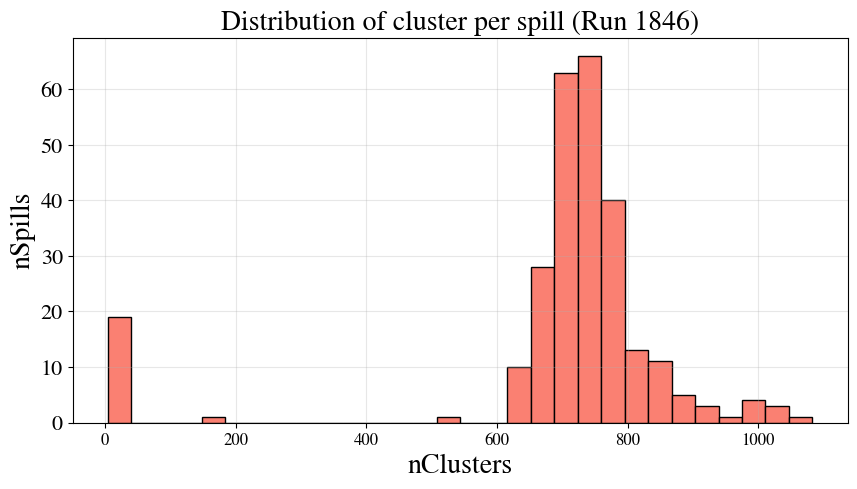

Total Clusters found in these spills: 187017
Average Clusters per 'Active' Spill: 695.23


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(activity_df['nCLusters_in_spill'], bins=30, color='salmon', edgecolor='black')
plt.title(f"Distribution of cluster per spill (Run {run_number})")
plt.xlabel("nClusters")
plt.ylabel("nSpills")
plt.grid(alpha=0.3)
plt.show()

print(f"Total Clusters found in these spills: {activity_df['nCLusters_in_spill'].sum()}")
print(f"Average Clusters per 'Active' Spill: {activity_df['nCLusters_in_spill'].mean():.2f}")

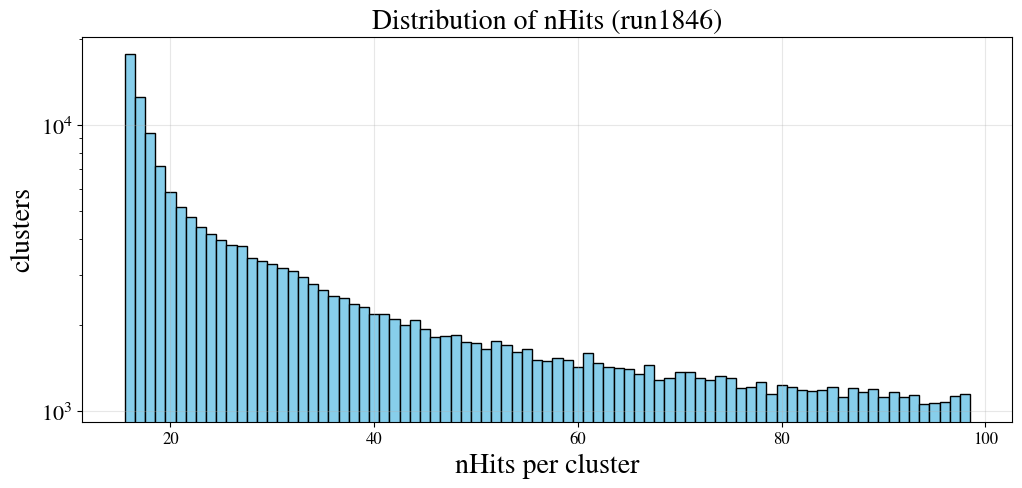

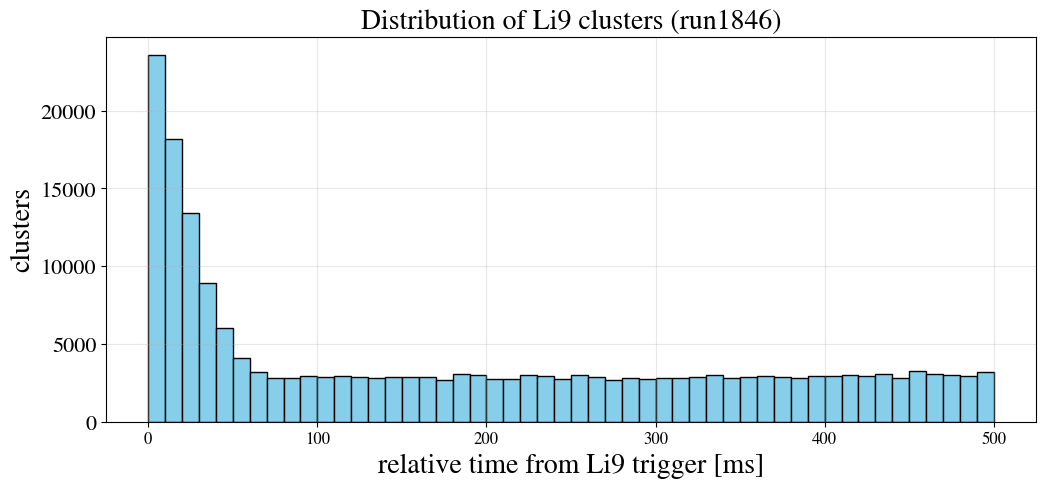

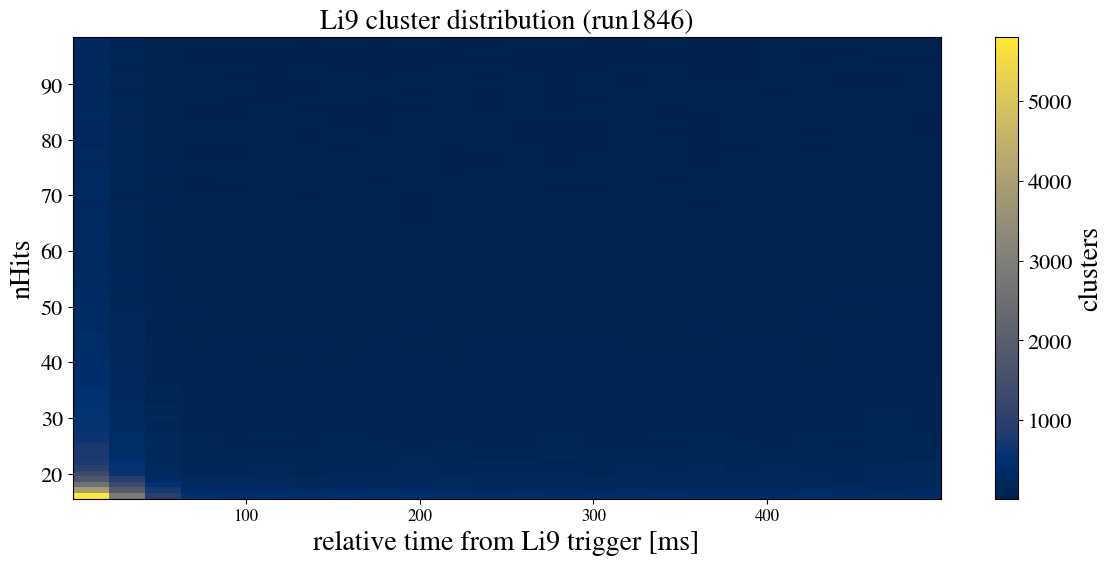

In [17]:
# -------------------------
# 2. 1D Histograms
# -------------------------

# Histogram: nHits per cluster
plt.figure(figsize=(12,5))
n_bins = np.arange(df['nHits'].min(), df['nHits'].max()+2) - 0.5            # +2 ensures the top-most value lands in a bin, the -0.5 centers bins on integers.
plt.hist(df['nHits'], bins=n_bins, color='skyblue', edgecolor='black')      #that's why we were missing the peak @ 40 before (only +1)
plt.yscale("log")
plt.xlabel("nHits per cluster")
plt.ylabel("clusters")
plt.title(f"Distribution of nHits (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# Histogram: relative time from Li9 window start
plt.figure(figsize=(12,5))
plt.hist(df['t_window_start_rel_ms'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("relative time from Li9 trigger [ms]")
plt.ylabel("clusters")
plt.title(f"Distribution of Li9 clusters (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# 3. 2D Histogram / Heatmap
# -------------------------

x = df['t_window_start_rel_ms']
y = df['nHits']

# Binning
x_bins = np.linspace(x.min(), x.max(), 25)       # finer bins for time
y_bins = np.arange(y.min()-0.5, y.max()+1.5, 1)  # integer nHits bins

H, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

plt.figure(figsize=(14,6))
plt.pcolormesh(xedges, yedges, H.T, cmap='cividis', shading='auto')
plt.colorbar(label='clusters')
plt.xlabel('relative time from Li9 trigger [ms]')
plt.ylabel('nHits')
plt.title(f'Li9 cluster distribution (run{run_number})')
plt.show()